# 11 Model Tuning on Dev-Noisy (Lazy Feature MLP)

This notebook performs **model tuning** for the lazy-feature MLP using dev-noisy data.

Tuning targets in this notebook:
- model checkpoint selection (compare multiple lazy MLP checkpoints)
- decision threshold selection (choose threshold that maximizes dev F1)

No test-noisy data is used in this notebook.

### Step 1: Import libraries
This step imports plotting, metrics, tensor, and utility libraries used throughout validation and checkpoint comparison.

In [1]:
import json
import sys
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

### Step 2: Resolve project paths and runtime config
This step finds the repository root, adds required source modules to Python path, and sets shared configuration for lazy validation.

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start] + list(start.parents):
        if (candidate / 'src').exists() and (candidate / 'data' / 'generated').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root from current working directory.')

ROOT = find_project_root(Path.cwd())
SRC_05 = ROOT / 'src' / '05_baseline_training'
SRC_07 = ROOT / 'src' / '07_lazy_feature_mlp'
for p in (SRC_05, SRC_07):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from baseline_mlp import BaselineMLP
from lazy_frame_dataset import VADLazyFrameDataset

DATA_ROOT = ROOT / 'data' / 'generated'
ARTIFACTS_DIR = ROOT / 'artifacts'
LAZY_CHECKPOINT_DIR = ARTIFACTS_DIR / 'lazy_checkpoints'

BATCH_SIZE = 2048
NUM_WORKERS = 0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MANIFEST_TYPE = 'noisy'
NORM_STATS_PATH = DATA_ROOT / 'train' / 'features' / 'noisy_norm_stats.npz'
DEV_SUBSET_FRACTION = None  # Set to e.g. 0.3 for quick checks
CONTEXT_LEFT = 5
CONTEXT_RIGHT = 5

CHECKPOINT_FILENAME = 'best_model.pt'
CHECKPOINT_NAME_CONTAINS = 'lazy_mlp'
THRESHOLDS = np.linspace(0.05, 0.95, 19)
TOP_K_PLOTS = 10

print('Project root          :', ROOT)
print('Step 05 src           :', SRC_05)
print('Step 07 src           :', SRC_07)
print('Data root             :', DATA_ROOT)
print('Lazy checkpoint dir   :', LAZY_CHECKPOINT_DIR)
print('Norm stats path       :', NORM_STATS_PATH)
print('Device                :', DEVICE)

Project root          : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL
Step 05 src           : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/05_baseline_training
Step 07 src           : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/src/07_lazy_feature_mlp
Data root             : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated
Lazy checkpoint dir   : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/lazy_checkpoints
Norm stats path       : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/data/generated/train/features/noisy_norm_stats.npz
Device                : cuda


### Step 3: Define helper functions
This step defines reusable helpers for checkpoint loading, architecture inference, lazy dataloader construction, and metrics computation.

In [3]:
def _extract_state_dict(obj):
    if isinstance(obj, dict):
        if 'state_dict' in obj and isinstance(obj['state_dict'], dict):
            return obj['state_dict']
        if 'model_state_dict' in obj and isinstance(obj['model_state_dict'], dict):
            return obj['model_state_dict']
    return obj


def _infer_mlp_shape_from_state(state_dict):
    linear_layers = []
    for k, v in state_dict.items():
        if not (k.startswith('backbone.') and k.endswith('.weight')):
            continue
        if not hasattr(v, 'shape') or len(v.shape) != 2:
            continue
        parts = k.split('.')
        if len(parts) < 3 or not parts[1].isdigit():
            continue
        idx = int(parts[1])
        out_dim, in_dim = int(v.shape[0]), int(v.shape[1])
        linear_layers.append((idx, in_dim, out_dim))

    if not linear_layers:
        raise RuntimeError('Could not infer backbone layers from checkpoint state_dict.')

    linear_layers.sort(key=lambda t: t[0])
    input_dim = linear_layers[0][1]
    hidden_dims = tuple(layer[2] for layer in linear_layers)
    dropout = 0.1 if len(linear_layers) >= 2 and (linear_layers[1][0] - linear_layers[0][0] == 3) else 0.0
    return input_dim, hidden_dims, dropout


def load_model_from_checkpoint(checkpoint_path: Path, device: torch.device) -> BaselineMLP:
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = _extract_state_dict(raw)
    if not isinstance(state, dict):
        raise RuntimeError('Checkpoint does not contain a valid state_dict.')

    input_dim, hidden_dims, dropout = _infer_mlp_shape_from_state(state)
    model = BaselineMLP(input_dim=input_dim, hidden_dims=hidden_dims, dropout=dropout)
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    return model


def build_lazy_dev_loader():
    dev_dataset = VADLazyFrameDataset(
        generated_dir=DATA_ROOT,
        split='dev',
        manifest_type=MANIFEST_TYPE,
        norm_stats_path=NORM_STATS_PATH,
        subset_fraction=DEV_SUBSET_FRACTION,
        context_left=CONTEXT_LEFT,
        context_right=CONTEXT_RIGHT,
    )
    return DataLoader(
        dev_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )


def collect_logits_labels(loader, model, device):
    logits_all = []
    labels_all = []

    with torch.no_grad():
        for batch in loader:
            x = batch['x'].to(device, non_blocking=True)
            y = batch['y']

            logits = model(x).squeeze(-1).detach().cpu().numpy()
            labels = y.detach().cpu().numpy().astype(np.int64)

            logits_all.append(logits)
            labels_all.append(labels)

    if not logits_all:
        raise RuntimeError('No samples collected from loader.')

    return np.concatenate(logits_all), np.concatenate(labels_all)


def metrics_at_threshold(probs, labels, thr=0.5):
    pred = (probs >= thr).astype(np.int64)
    y = labels.astype(np.int64)

    tp = int(np.sum((pred == 1) & (y == 1)))
    tn = int(np.sum((pred == 0) & (y == 0)))
    fp = int(np.sum((pred == 1) & (y == 0)))
    fn = int(np.sum((pred == 0) & (y == 1)))

    acc = (tp + tn) / max(1, tp + tn + fp + fn)
    prec = tp / max(1, tp + fp)
    rec = tp / max(1, tp + fn)
    f1 = (2.0 * prec * rec) / max(1e-12, (prec + rec))

    far = fp / max(1, fp + tn)
    miss_rate = fn / max(1, fn + tp)

    return {
        'threshold': float(thr),
        'accuracy': float(acc),
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'far': float(far),
        'miss_rate': float(miss_rate),
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
    }

### Step 4: Build dev dataloader and discover lazy checkpoints
This step builds the dev-noisy lazy dataloader and discovers checkpoint folders under artifacts/lazy_checkpoints.

In [4]:
loader = build_lazy_dev_loader()

ckpt_candidates = sorted([p for p in LAZY_CHECKPOINT_DIR.rglob(CHECKPOINT_FILENAME) if p.is_file()])
if CHECKPOINT_NAME_CONTAINS:
    key = CHECKPOINT_NAME_CONTAINS.lower()
    ckpt_candidates = [p for p in ckpt_candidates if key in str(p.parent.name).lower()]

print('Dataset size          :', len(loader.dataset))
print('Checkpoint candidates :', len(ckpt_candidates))
for p in ckpt_candidates[:20]:
    print(' -', p.parent.name, '/', p.name)

if not ckpt_candidates:
    raise FileNotFoundError(f'No lazy checkpoint files found under: {LAZY_CHECKPOINT_DIR}')

Loaded 500 examples from dev noisy manifest
Frame dataset: 1088453 total frames from 500 sequences
Dataset size          : 1088453
Checkpoint candidates : 12
 - lazy_mlp_lr0.0003_wd0_dr0.0_seed42 / best_model.pt
 - lazy_mlp_lr0.0003_wd0_dr0.1_seed42 / best_model.pt
 - lazy_mlp_lr0.0003_wd1e-4_dr0.0_seed42 / best_model.pt
 - lazy_mlp_lr0.0003_wd1e-4_dr0.1_seed42 / best_model.pt
 - lazy_mlp_lr0.0003_wd1e-5_dr0.0_seed42 / best_model.pt
 - lazy_mlp_lr0.0003_wd1e-5_dr0.1_seed42 / best_model.pt
 - lazy_mlp_lr0.001_wd0_dr0.0_seed42 / best_model.pt
 - lazy_mlp_lr0.001_wd0_dr0.1_seed42 / best_model.pt
 - lazy_mlp_lr0.001_wd1e-4_dr0.0_seed42 / best_model.pt
 - lazy_mlp_lr0.001_wd1e-4_dr0.1_seed42 / best_model.pt
 - lazy_mlp_lr0.001_wd1e-5_dr0.0_seed42 / best_model.pt
 - lazy_mlp_lr0.001_wd1e-5_dr0.1_seed42 / best_model.pt


### Step 5: Evaluate all checkpoints and tune threshold per checkpoint
This step runs inference for each lazy checkpoint on dev-noisy, performs threshold sweep, and ranks checkpoints by best dev F1.

In [5]:
results = []
failures = []

best_model = None
all_logits = None
all_labels = None
probs = None

for i, ckpt in enumerate(ckpt_candidates, start=1):
    try:
        model = load_model_from_checkpoint(ckpt, DEVICE)
        logits_i, labels_i = collect_logits_labels(loader, model, DEVICE)
        probs_i = 1.0 / (1.0 + np.exp(-logits_i))

        sweep_i = [metrics_at_threshold(probs_i, labels_i, thr=float(t)) for t in THRESHOLDS]
        best_idx = int(np.argmax([m['f1'] for m in sweep_i]))
        best_point = sweep_i[best_idx]

        result = {
            'checkpoint': str(ckpt),
            'checkpoint_name': ckpt.parent.name,
            'best_threshold': best_point['threshold'],
            'accuracy': best_point['accuracy'],
            'precision': best_point['precision'],
            'recall': best_point['recall'],
            'f1': best_point['f1'],
            'far': best_point['far'],
            'miss_rate': best_point['miss_rate'],
            'tp': best_point['tp'],
            'tn': best_point['tn'],
            'fp': best_point['fp'],
            'fn': best_point['fn'],
            'sweep': sweep_i,
        }
        results.append(result)

        if best_model is None or result['f1'] > best_model['f1']:
            best_model = result
            all_logits = logits_i
            all_labels = labels_i
            probs = probs_i

        print(
            f"[{i:02d}/{len(ckpt_candidates)}] OK  {ckpt.parent.name} | "
            f"F1={result['f1']:.6f}, P={result['precision']:.4f}, R={result['recall']:.4f}, "
            f"FAR={result['far']:.4f}, Miss={result['miss_rate']:.4f} @thr={result['best_threshold']:.2f}"
        )
    except Exception as e:
        failures.append((str(ckpt), repr(e)))
        print(f"[{i:02d}/{len(ckpt_candidates)}] FAIL {ckpt.parent.name} | {e}")

if not results:
    raise RuntimeError('No checkpoint evaluated successfully.')

ranked = sorted(results, key=lambda r: r['f1'], reverse=True)
best_model = ranked[0]
best_threshold = float(best_model['best_threshold'])
preds = (probs >= best_threshold).astype(int)

print('\nBest checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print(
    "Best metrics   : "
    f"F1={best_model['f1']:.6f}, "
    f"Precision={best_model['precision']:.6f}, "
    f"Recall={best_model['recall']:.6f}, "
    f"FAR={best_model['far']:.6f}, "
    f"MissRate={best_model['miss_rate']:.6f}"
)
print('Failures       :', len(failures))

[01/12] OK  lazy_mlp_lr0.0003_wd0_dr0.0_seed42 | F1=0.866230, P=0.8208, R=0.9169, FAR=0.4494, Miss=0.0831 @thr=0.40
[02/12] OK  lazy_mlp_lr0.0003_wd0_dr0.1_seed42 | F1=0.866470, P=0.8216, R=0.9165, FAR=0.4469, Miss=0.0835 @thr=0.40
[03/12] OK  lazy_mlp_lr0.0003_wd1e-4_dr0.0_seed42 | F1=0.865740, P=0.8194, R=0.9176, FAR=0.4541, Miss=0.0824 @thr=0.40
[04/12] OK  lazy_mlp_lr0.0003_wd1e-4_dr0.1_seed42 | F1=0.866300, P=0.8194, R=0.9189, FAR=0.4548, Miss=0.0811 @thr=0.40
[05/12] OK  lazy_mlp_lr0.0003_wd1e-5_dr0.0_seed42 | F1=0.865963, P=0.8378, R=0.8961, FAR=0.3897, Miss=0.1039 @thr=0.45
[06/12] OK  lazy_mlp_lr0.0003_wd1e-5_dr0.1_seed42 | F1=0.866533, P=0.8207, R=0.9178, FAR=0.4504, Miss=0.0822 @thr=0.40
[07/12] OK  lazy_mlp_lr0.001_wd0_dr0.0_seed42 | F1=0.869255, P=0.8447, R=0.8953, FAR=0.3696, Miss=0.1047 @thr=0.50
[08/12] OK  lazy_mlp_lr0.001_wd0_dr0.1_seed42 | F1=0.868842, P=0.8293, R=0.9124, FAR=0.4217, Miss=0.0876 @thr=0.45
[09/12] OK  lazy_mlp_lr0.001_wd1e-4_dr0.0_seed42 | F1=0.868654

**Output explanation**

The evaluation on the dev-noisy dataset shows that the best-performing model achieves an F1 score of 0.869 with a learning rate of 0.001, weight decay of 1e-5, and no dropout, using a threshold of 0.45. The results across different checkpoints are very close, indicating that the model is stable and not highly sensitive to hyperparameter changes such as learning rate, weight decay, or dropout. This suggests that the training setup is robust. Additionally, a threshold around 0.45 provides a good balance between precision and recall, maintaining a low miss rate while keeping the false alarm rate at a moderate level.

### Step 6: Print checkpoint leaderboard
This step prints a ranked table of all successfully evaluated lazy checkpoints.

In [6]:
print('Top checkpoints by dev F1:')
print('-' * 132)
print(f"{'rank':>4s}  {'checkpoint':<55s}  {'thr':>5s}  {'f1':>9s}  {'acc':>9s}  {'prec':>9s}  {'rec':>9s}  {'far':>9s}  {'miss':>9s}")
print('-' * 132)

for idx, r in enumerate(ranked, start=1):
    print(
        f"{idx:>4d}  {r['checkpoint_name']:<55.55s}  {r['best_threshold']:>5.2f}  "
        f"{r['f1']:>9.6f}  {r['accuracy']:>9.6f}  {r['precision']:>9.6f}  {r['recall']:>9.6f}  "
        f"{r['far']:>9.6f}  {r['miss_rate']:>9.6f}"
    )

if failures:
    print('\nFailed checkpoints:')
    for ckpt, err in failures:
        print(' -', Path(ckpt).parent.name, '|', err)

Top checkpoints by dev F1:
------------------------------------------------------------------------------------------------------------------------------------
rank  checkpoint                                                 thr         f1        acc       prec        rec        far       miss
------------------------------------------------------------------------------------------------------------------------------------
   1  lazy_mlp_lr0.001_wd1e-5_dr0.0_seed42                      0.45   0.869400   0.809985   0.828846   0.914128   0.423861   0.085872
   2  lazy_mlp_lr0.001_wd0_dr0.0_seed42                         0.50   0.869255   0.813666   0.844702   0.895279   0.369591   0.104721
   3  lazy_mlp_lr0.001_wd0_dr0.1_seed42                         0.45   0.868842   0.809420   0.829289   0.912357   0.421717   0.087643
   4  lazy_mlp_lr0.001_wd1e-5_dr0.1_seed42                      0.45   0.868731   0.809276   0.829252   0.912156   0.421735   0.087844
   5  lazy_mlp_lr0.001_wd1e-4_dr

**Output explanation**

The evaluation on the dev-noisy dataset shows that the best-performing model achieves an F1 score of 0.869 with a learning rate of 0.001, weight decay of 1e-5, and no dropout, using a threshold of 0.45. The top configurations have very similar F1 scores, indicating that the model performance is stable and not highly sensitive to changes in hyperparameters such as weight decay and dropout.

Models with a higher learning rate (0.001) consistently outperform those with a lower learning rate (0.0003), suggesting that a larger learning rate is more suitable for this task. Additionally, the optimal threshold values fall between 0.40 and 0.50, with 0.45 providing a good balance between precision and recall. The best model achieves high recall while maintaining reasonable precision, resulting in a low miss rate, although the false alarm rate remains moderate. Overall, these results demonstrate that the training setup is robust and that hyperparameter tuning mainly provides marginal improvements.

### Step 7: Compare metrics across top checkpoints
This step visualizes accuracy, precision, recall, F1, FAR, and miss rate across top lazy checkpoints.

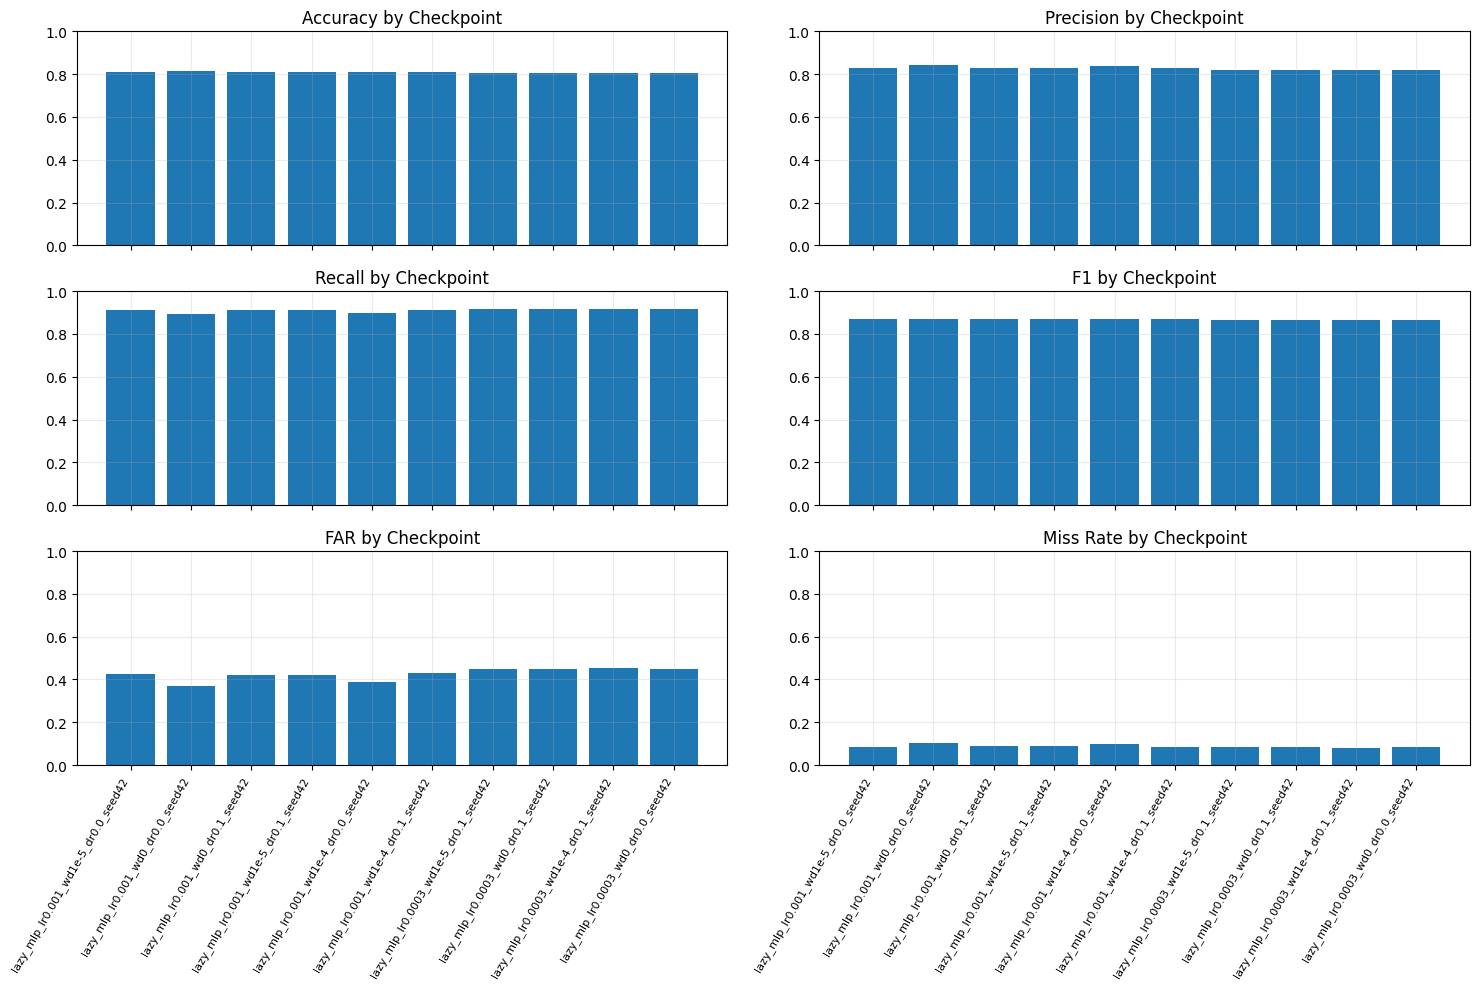

Best checkpoint: lazy_mlp_lr0.001_wd1e-5_dr0.0_seed42
Best threshold : 0.45
Best metrics   : acc=0.809985,  prec=0.828846,  rec=0.914128,  f1=0.869400,  far=0.423861,  miss=0.085872


In [7]:
top = ranked[: min(TOP_K_PLOTS, len(ranked))]
names = [r['checkpoint_name'] for r in top]
x = np.arange(len(top))

acc_vals = [r['accuracy'] for r in top]
prec_vals = [r['precision'] for r in top]
rec_vals = [r['recall'] for r in top]
f1_vals = [r['f1'] for r in top]
far_vals = [r['far'] for r in top]
miss_vals = [r['miss_rate'] for r in top]

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
axes = axes.ravel()

axes[0].bar(x, acc_vals)
axes[0].set_title('Accuracy by Checkpoint')
axes[0].set_ylim(0, 1)

axes[1].bar(x, prec_vals)
axes[1].set_title('Precision by Checkpoint')
axes[1].set_ylim(0, 1)

axes[2].bar(x, rec_vals)
axes[2].set_title('Recall by Checkpoint')
axes[2].set_ylim(0, 1)

axes[3].bar(x, f1_vals)
axes[3].set_title('F1 by Checkpoint')
axes[3].set_ylim(0, 1)

axes[4].bar(x, far_vals)
axes[4].set_title('FAR by Checkpoint')
axes[4].set_ylim(0, 1)

axes[5].bar(x, miss_vals)
axes[5].set_title('Miss Rate by Checkpoint')
axes[5].set_ylim(0, 1)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)

plt.tight_layout()
plt.show()

print('Best checkpoint:', best_model['checkpoint_name'])
print('Best threshold :', f"{best_threshold:.2f}")
print('Best metrics   :',
      f"acc={best_model['accuracy']:.6f}, ",
      f"prec={best_model['precision']:.6f}, ",
      f"rec={best_model['recall']:.6f}, ",
      f"f1={best_model['f1']:.6f}, ",
      f"far={best_model['far']:.6f}, ",
      f"miss={best_model['miss_rate']:.6f}")

**Output explanation**

The plots show consistent performance across all checkpoints, indicating that the model is stable and not sensitive to hyperparameter changes. Accuracy is around 0.80, precision around 0.82–0.84, and recall remains high (0.90–0.92), resulting in similar F1 scores (0.86–0.87). A trade-off between FAR and miss rate is observed: higher recall leads to lower miss rate but higher FAR. Overall, the differences are small, confirming that the training setup is robust.

### Step 8: Visualize confusion matrix for best checkpoint
This step plots the confusion matrix of the selected best lazy checkpoint using its tuned decision threshold.

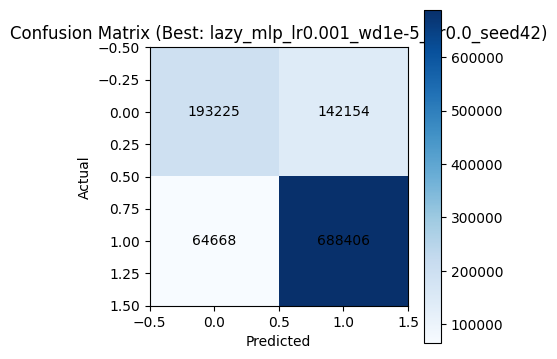

In [8]:
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(4.5, 4.0))
plt.imshow(cm, cmap='Blues')
plt.title(f"Confusion Matrix (Best: {best_model['checkpoint_name']})")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

**Output explanation**

The confusion matrix shows that the model correctly identifies most speech frames (688,406 true positives) and a large number of non-speech frames (193,225 true negatives). However, there are still some false positives (142,154), which explains the moderate false alarm rate, and fewer false negatives (64,668), indicating a low miss rate.
Overall, the model favors higher recall by detecting most speech, but at the cost of more false alarms, which is consistent with the earlier metrics.

### Step 9: Plot ROC curve for best checkpoint
This step computes and visualizes ROC and AUC for the selected best lazy checkpoint on dev-noisy.

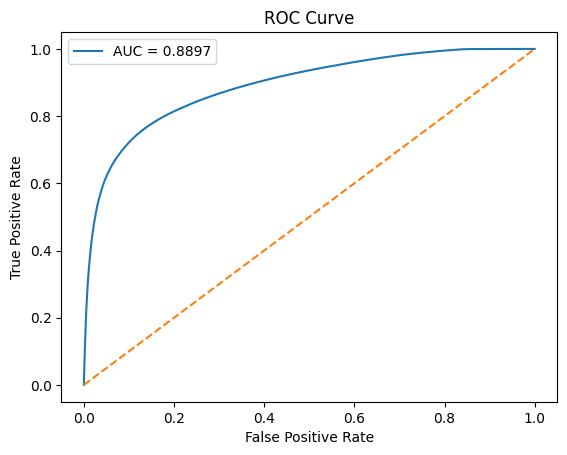

In [9]:
fpr, tpr, _ = roc_curve(all_labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

**Output explanation**

The ROC curve shows the trade-off between true positive rate and false positive rate across different thresholds. The curve is well above the diagonal baseline, and the AUC of 0.8897 indicates good overall classification performance. This means the model can effectively distinguish between speech and non-speech frames, and different thresholds can be chosen depending on the desired balance between recall and false alarms.

### Step 10: Plot precision-recall curve for best checkpoint
This step visualizes the precision-recall trade-off for the selected best lazy checkpoint.

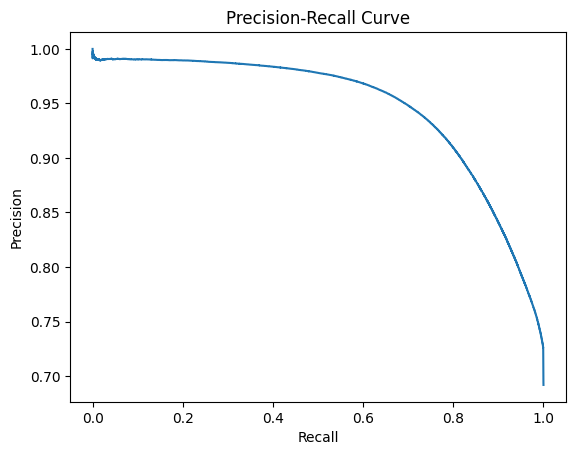

In [10]:
precision_vals, recall_vals, _ = precision_recall_curve(all_labels, probs)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.show()

**Output explanation**

The precision-recall curve shows the trade-off between precision and recall across different thresholds. Precision remains very high at lower recall levels and gradually decreases as recall increases, indicating that the model becomes less precise when trying to capture more speech. Overall, the curve demonstrates strong performance, as the model maintains high precision over a wide range of recall values, confirming its effectiveness in detecting speech while controlling false positives.

### Step 11: Visualize F1 versus threshold
This step plots the F1-threshold curve for the best checkpoint to inspect threshold behavior.

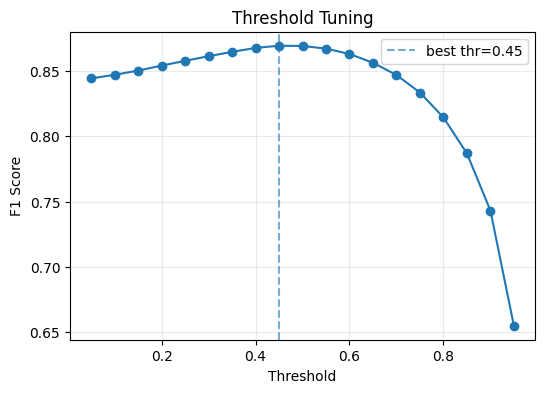

Best threshold from curve: 0.45
Best F1 from curve       : 0.869400


In [11]:
thresholds = THRESHOLDS
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(np.int64)
    f1_scores.append(f1_score(all_labels, preds_t))

best_idx = int(np.argmax(f1_scores))
best_thr_curve = float(thresholds[best_idx])
best_f1_curve = float(f1_scores[best_idx])

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, marker='o')
plt.axvline(best_thr_curve, linestyle='--', alpha=0.6, label=f'best thr={best_thr_curve:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold Tuning')
plt.grid(alpha=0.25)
plt.legend()
plt.show()

print(f"Best threshold from curve: {best_thr_curve:.2f}")
print(f"Best F1 from curve       : {best_f1_curve:.6f}")

**Output explanation**

The threshold tuning plot shows how F1 score changes with different decision thresholds. The F1 score increases as the threshold rises, reaches its peak around 0.45, and then decreases as the threshold becomes too high. This indicates that a threshold of 0.45 provides the best balance between precision and recall. Lower thresholds lead to more false positives, while higher thresholds increase missed detections.

### Step 12: Export evaluation artifacts and tuned configuration
This step saves prediction arrays, checkpoint leaderboard, and final tuned config for downstream use.

In [12]:
eval_dir = ARTIFACTS_DIR / 'eval_outputs_lazy_noisy_mlp'
eval_dir.mkdir(parents=True, exist_ok=True)

np.save(eval_dir / 'eval_logits.npy', all_logits)
np.save(eval_dir / 'eval_probs.npy', probs)
np.save(eval_dir / 'eval_labels.npy', all_labels)

with open(eval_dir / 'checkpoint_leaderboard.json', 'w', encoding='utf-8') as f:
    json.dump(
        [
            {
                'checkpoint': r['checkpoint'],
                'checkpoint_name': r['checkpoint_name'],
                'best_threshold': r['best_threshold'],
                'accuracy': r['accuracy'],
                'precision': r['precision'],
                'recall': r['recall'],
                'f1': r['f1'],
                'far': r['far'],
                'miss_rate': r['miss_rate'],
                'tp': r['tp'],
                'tn': r['tn'],
                'fp': r['fp'],
                'fn': r['fn'],
            }
            for r in ranked
        ],
        f,
        indent=2,
    )

lazy_config_path = ARTIFACTS_DIR / 'final_tuned_config_lazy_noisy_mlp.json'
with open(lazy_config_path, 'w', encoding='utf-8') as f:
    json.dump(
        {
            'checkpoint': best_model['checkpoint'],
            'threshold': best_threshold,
            'dev_metrics': {
                'accuracy': best_model['accuracy'],
                'precision': best_model['precision'],
                'recall': best_model['recall'],
                'f1': best_model['f1'],
                'far': best_model['far'],
                'miss_rate': best_model['miss_rate'],
                'tp': best_model['tp'],
                'tn': best_model['tn'],
                'fp': best_model['fp'],
                'fn': best_model['fn'],
            },
        },
        f,
        indent=2,
    )

print('Saved evaluation arrays to:', eval_dir)
print('Saved leaderboard to     :', eval_dir / 'checkpoint_leaderboard.json')
print('Saved tuned config to    :', lazy_config_path)

Saved evaluation arrays to: /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_lazy_noisy_mlp
Saved leaderboard to     : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/eval_outputs_lazy_noisy_mlp/checkpoint_leaderboard.json
Saved tuned config to    : /home/jasmi/Noise-Robust-Voice-Activity-Detection-FINAL/artifacts/final_tuned_config_lazy_noisy_mlp.json
